# VisionZero: Road Accident Severity Predictor




## Install Libraries

In [13]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imblearn category_encoders -q

## Import All Required Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, f1_score, precision_score, recall_score)
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
import category_encoders as ce
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')

## Mount Google Drive & Load Data


In [15]:
from google.colab import files
uploaded = files.upload()

csv_filename = list(uploaded.keys())[0]
print(f"File uploaded: {csv_filename}")

df = pd.read_csv(csv_filename)
print(f"\nDataset loaded successfully!")
print(f"  Shape: {df.shape}")
print(f"  Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Saving Road.csv to Road (1).csv
File uploaded: Road (1).csv

Dataset loaded successfully!
  Shape: (12316, 32)
  Rows: 12316, Columns: 32


## Data Exploration & Analysis

In [16]:
import pandas as pd

df = pd.read_csv('/content/Road.csv')
summary = df.describe(include='all')
display(summary)

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
count,12316,12316,12316,12316,11575,11737,11487,11366,11834,8388,...,12008,12316,12316,12316,12316,9118,9681,12316,12316,12316
unique,1074,7,5,3,7,4,7,17,4,6,...,13,4,3,6,4,7,5,9,20,3
top,15:30:00,Friday,18-30,Male,Junior high school,Employee,5-10yr,Automobile,Owner,Unknown,...,Going straight,Driver or rider,Male,na,3,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
freq,120,2041,4271,11437,7619,9627,3363,3205,10459,2883,...,8158,4944,5253,4443,7076,5903,9608,11390,2263,10415
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
numeric_df = df.select_dtypes(include=['number'])

if not numeric_df.empty:
    display(numeric_df.describe())
else:
    print('No numeric columns found in the dataset.')

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


Accident Severity Distribution:
Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

Percentage Distribution:
Accident_severity
Slight Injury     84.564794
Serious Injury    14.152322
Fatal injury       1.282884
Name: proportion, dtype: float64
Percentage Distribution:


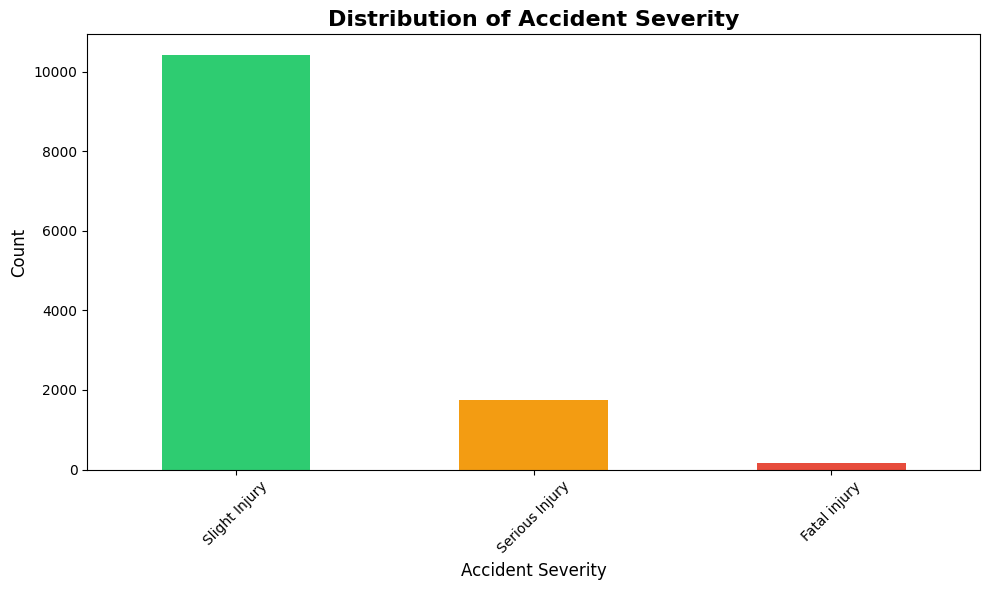

In [18]:
print("Accident Severity Distribution:")
severity_counts = df['Accident_severity'].value_counts()
print(severity_counts)
print("\nPercentage Distribution:")
print(df['Accident_severity'].value_counts(normalize=True) * 100)

print("Percentage Distribution:")
plt.figure(figsize=(10, 6))
severity_counts.plot(kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('Distribution of Accident Severity', fontsize=16, fontweight='bold')
plt.xlabel('Accident Severity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

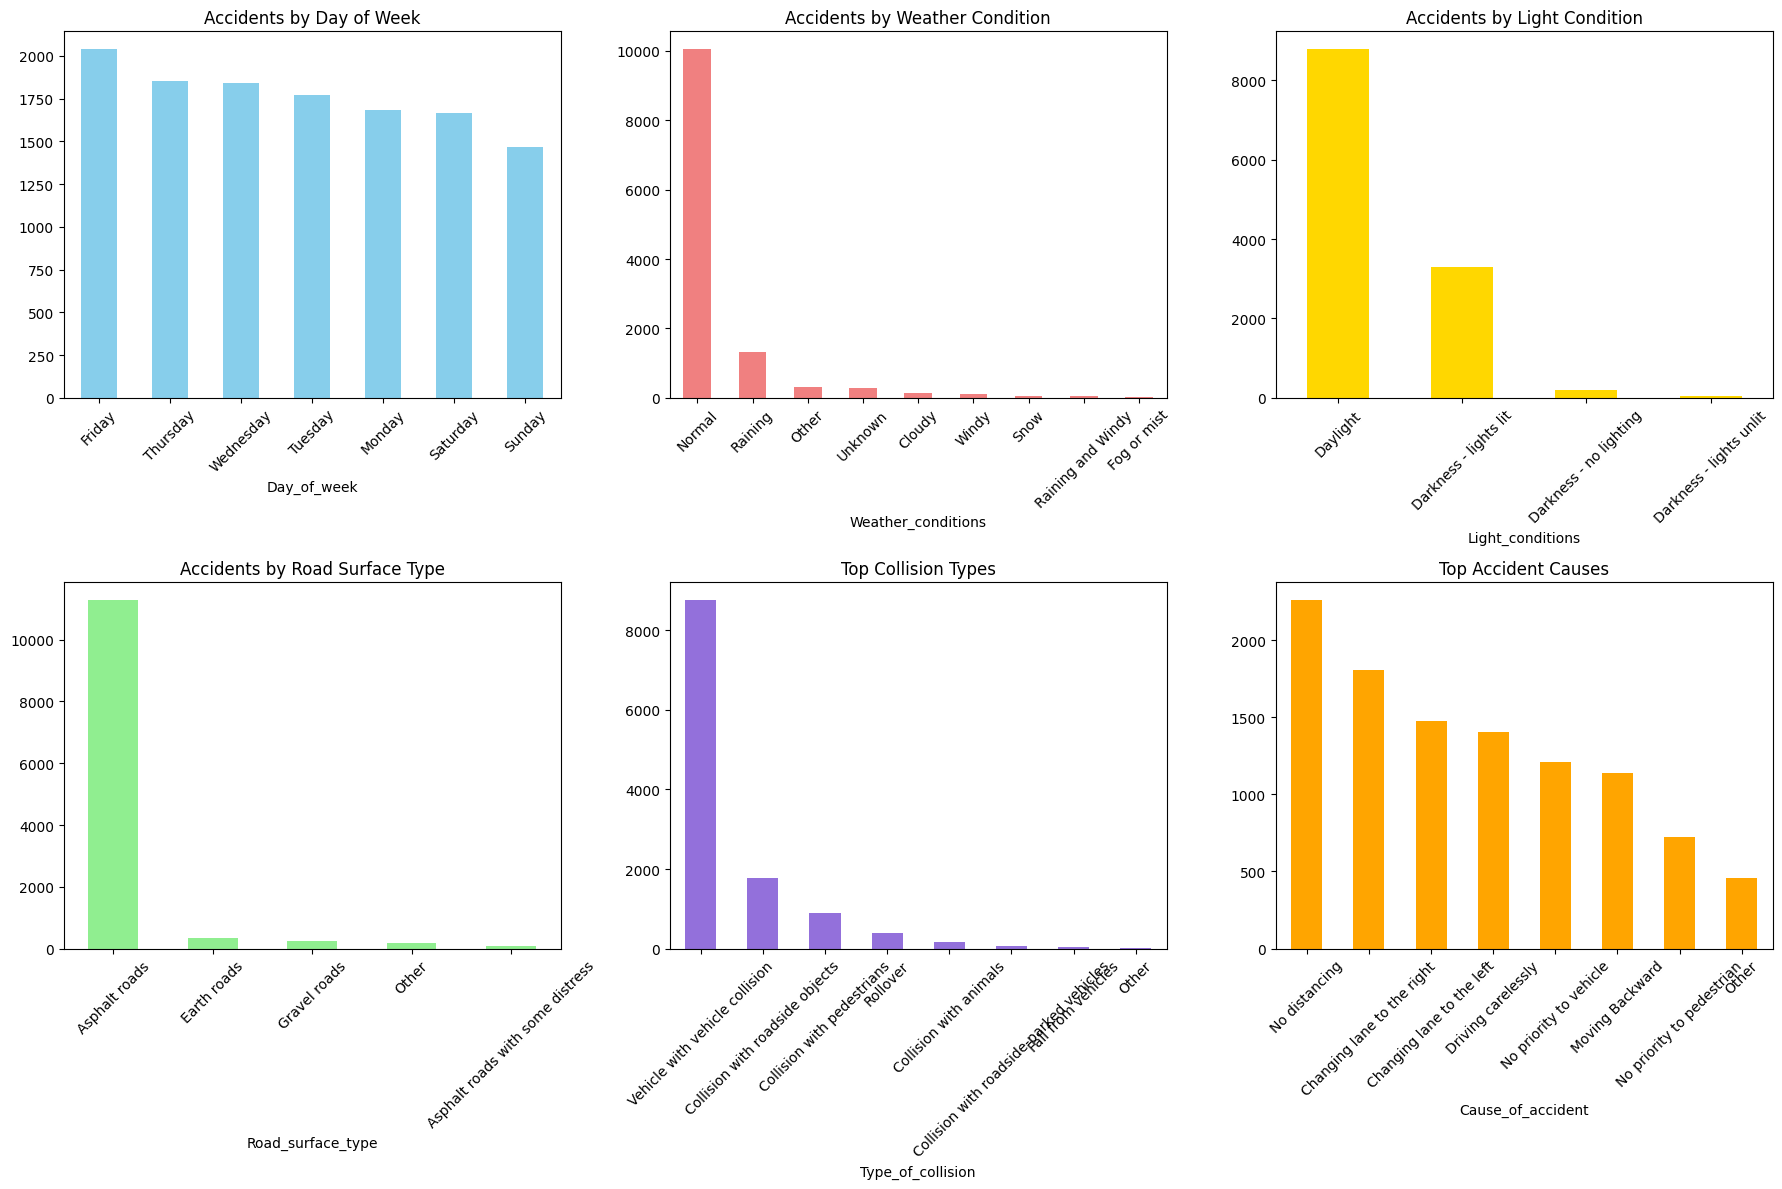

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

df['Day_of_week'].value_counts().plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Accidents by Day of Week')
axes[0,0].tick_params(axis='x', rotation=45)

df['Weather_conditions'].value_counts().plot(kind='bar', ax=axes[0,1], color='lightcoral')
axes[0,1].set_title('Accidents by Weather Condition')
axes[0,1].tick_params(axis='x', rotation=45)

df['Light_conditions'].value_counts().plot(kind='bar', ax=axes[0,2], color='gold')
axes[0,2].set_title('Accidents by Light Condition')
axes[0,2].tick_params(axis='x', rotation=45)

df['Road_surface_type'].value_counts().plot(kind='bar', ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Accidents by Road Surface Type')
axes[1,0].tick_params(axis='x', rotation=45)

df['Type_of_collision'].value_counts().head(8).plot(kind='bar', ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('Top Collision Types')
axes[1,1].tick_params(axis='x', rotation=45)

df['Cause_of_accident'].value_counts().head(8).plot(kind='bar', ax=axes[1,2], color='orange')
axes[1,2].set_title('Top Accident Causes')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

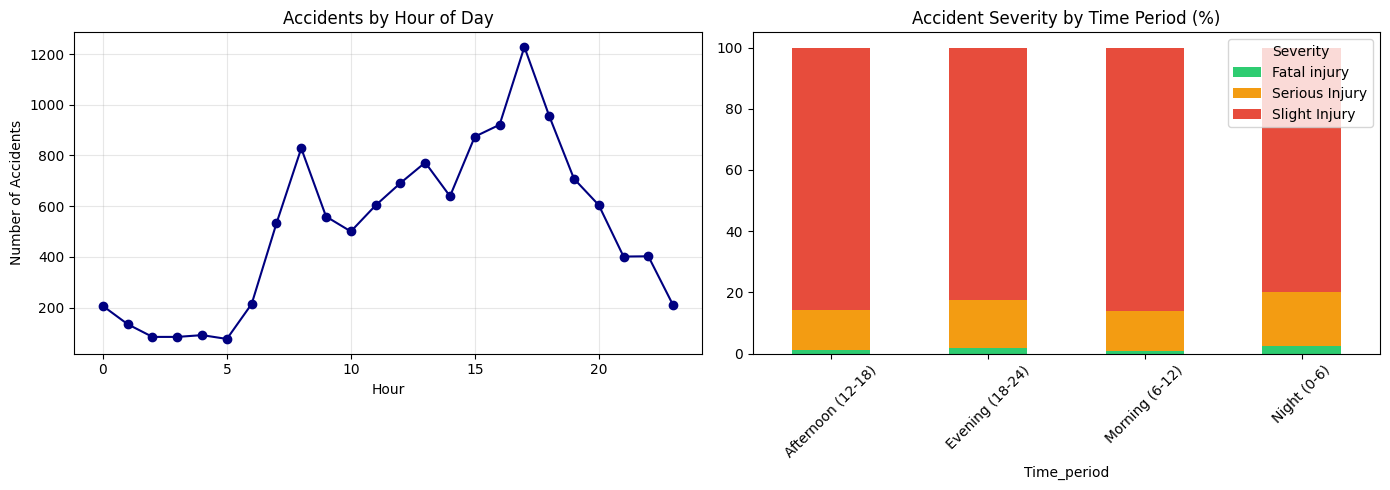

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

def categorize_time(hour):
    if 6 <= hour < 12:
        return 'Morning (6-12)'
    elif 12 <= hour < 18:
        return 'Afternoon (12-18)'
    elif 18 <= hour < 24:
        return 'Evening (18-24)'
    else:
        return 'Night (0-6)'

df['Time_period'] = df['Hour'].apply(categorize_time)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Hour'].value_counts().sort_index().plot(kind='line', ax=axes[0], marker='o', color='navy')
axes[0].set_title('Accidents by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Accidents')
axes[0].grid(True, alpha=0.3)

time_severity = pd.crosstab(df['Time_period'], df['Accident_severity'], normalize='index') * 100
time_severity.plot(kind='bar', stacked=True, ax=axes[1],
                   color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('Accident Severity by Time Period (%)')
axes[1].legend(title='Severity')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Feature Engineering

In [21]:
df_engineered = df.copy()
df_engineered['Is_Night'] = df_engineered['Light_conditions'].apply(
    lambda x: 1 if 'Dark' in str(x) else 0
)

df_engineered['Bad_Weather'] = df_engineered['Weather_conditions'].isin(
    ['Rain', 'Fog', 'Storm']
).astype(int)

df_engineered['High_Risk_Scenario'] = df_engineered['Is_Night'] * df_engineered['Bad_Weather']

# Interaction Features
df_engineered['Road_Weather'] = (df_engineered['Road_surface_type'].astype(str) + "_" + df_engineered['Weather_conditions'].astype(str))
df_engineered['Vehicle_Road'] = (df_engineered['Type_of_vehicle'].astype(str) + "_" + df_engineered['Road_surface_type'].astype(str))
df_engineered['Time_Weather'] = (df_engineered['Time'].astype(str) + "_" + df_engineered['Weather_conditions'].astype(str))
df_engineered['Driver_Age_Experience'] = (df_engineered['Age_band_of_driver'].astype(str) + "_" + df_engineered['Driving_experience'].astype(str))
df_engineered['Junction_Road_Type'] = (df_engineered['Types_of_Junction'].astype(str) + "_" + df_engineered['Road_surface_type'].astype(str))
df_engineered['High_Casualty_Count'] = (df_engineered['Number_of_casualties'] > df_engineered['Number_of_casualties'].median()).astype(int)
df_engineered['Multiple_Vehicles'] = (df_engineered['Number_of_vehicles_involved'] > 1).astype(int)
df_engineered['Young_Driver'] = df_engineered['Age_band_of_driver'].isin(['18-30']).astype(int)
df_engineered['Inexperienced_Driver'] = df_engineered['Driving_experience'].astype(str).str.contains(
    '2-5|Below 2', na=False
).astype(int)

df_engineered['Driver_Risk_Score'] = (df_engineered['Young_Driver'] +
                                       df_engineered['Inexperienced_Driver'] +
                                       df_engineered['Bad_Weather'] +
                                       df_engineered['Is_Night'])

print("4. Handling Rare Categories...")
for col in ['Type_of_vehicle', 'Road_surface_type']:
    if col in df_engineered.columns:
        freq = df_engineered[col].value_counts(normalize=True)
        rare = freq[freq < 0.01].index
        df_engineered[col] = df_engineered[col].replace(rare, 'Other')

print(f"  New Features Created: {df_engineered.shape[1] - df.shape[1]}")
print(f"  Total Features: {df_engineered.shape[1]}")

4. Handling Rare Categories...
  New Features Created: 13
  Total Features: 47


## Data Preprocessing & Target Encoding

In [25]:
print("\nRemoving Missing Values...")
df_clean = df_engineered.dropna()
print(f"  Rows after removing NaN: {df_clean.shape[0]}")

y = df_clean['Accident_severity']
X = df_clean.drop('Accident_severity', axis=1)

le = LabelEncoder()
y = le.fit_transform(y)
print(f"  Classes: {le.classes_}")
print(f"  Encoded: {np.unique(y)}")

high_card_cols = [
    'Weather_conditions', 'Road_surface_type', 'Type_of_vehicle', 'Road_Weather',
    'Vehicle_Road', 'Time_Weather', 'Driver_Age_Experience', 'Junction_Road_Type'
]

categorical_cols = X.select_dtypes(include='object').columns.tolist()
low_card_cols = [col for col in categorical_cols if col not in high_card_cols]

X_encoded = X.copy()
label_encoders = {}

for col in low_card_cols:
    le_col = LabelEncoder()
    X_encoded[col] = le_col.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le_col

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for col in high_card_cols:
    if col in X_encoded.columns:
        X_encoded[col] = 0.0

for train_idx, val_idx in kf.split(X, y):
    X_train_fold = X.iloc[train_idx].copy()
    X_val_fold = X.iloc[val_idx].copy()
    y_train_fold = y[train_idx]

    encoder = ce.TargetEncoder(cols=high_card_cols)
    encoder.fit(X_train_fold, y_train_fold)
    encoded_vals = encoder.transform(X_val_fold)

    for col in high_card_cols:
        if col in encoded_vals.columns:
            mask = pd.Series(False, index=X_encoded.index)
            mask.iloc[val_idx] = True
            X_encoded.loc[mask, col] = encoded_vals[col].values

scaler = StandardScaler()
numeric_cols = X_encoded.select_dtypes(include=[np.number]).columns.tolist()
X_scaled = X_encoded.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X_scaled[numeric_cols])
smote = SMOTE(random_state=42, k_neighbors=3, sampling_strategy={0: 200, 1: 300})

try:
    X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
except:
    smote = SMOTE(random_state=42, k_neighbors=3, sampling_strategy='not majority')
    X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print(f"  Original shape: {X.shape}")
print(f"  Resampled shape: {X_resampled.shape}")
print(f"  Class distribution after SMOTE: {np.unique(y_resampled, return_counts=True)}")


Removing Missing Values...
  Rows after removing NaN: 2889
  Classes: ['Fatal injury' 'Serious Injury' 'Slight Injury']
  Encoded: [0 1 2]
  Original shape: (2889, 46)
  Resampled shape: (7398, 46)
  Class distribution after SMOTE: (array([0, 1, 2]), array([2466, 2466, 2466]))


## Train-Test Split

In [26]:
feature_names = X_resampled.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print(f"  Shape: {X_train.shape}")
print(f"  Classes: {np.unique(y_train, return_counts=True)}")

print(f"  Shape: {X_test.shape}")
print(f"  Classes: {np.unique(y_test, return_counts=True)}")

print(f"  Training samples: {X_train.shape[0]} ({X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)")
print(f"  Test samples: {X_test.shape[0]} ({X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)")

  Shape: (5918, 46)
  Classes: (array([0, 1, 2]), array([1973, 1973, 1972]))
  Shape: (1480, 46)
  Classes: (array([0, 1, 2]), array([493, 493, 494]))
  Training samples: 5918 (80.0%)
  Test samples: 1480 (20.0%)


## Train XGBoost Model

In [28]:
class_weights = compute_sample_weight('balanced', y_train)

print("\n Initializing XGBoost Classifier...")
print("   Hyperparameters:")
print("   - n_estimators: 500")
print("   - max_depth: 7")
print("   - learning_rate: 0.03")
print("   - subsample: 0.7")
print("   - colsample_bytree: 0.85")

model = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.85,
    min_child_weight=1,
    gamma=2,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=2.5,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

model.fit(X_train, y_train, sample_weight=class_weights)

print(f"  Training samples: {X_train.shape[0]}")
print(f"  Features: {X_train.shape[1]}")
print(f"  Model type: {type(model).__name__}")


 Initializing XGBoost Classifier...
   Hyperparameters:
   - n_estimators: 500
   - max_depth: 7
   - learning_rate: 0.03
   - subsample: 0.7
   - colsample_bytree: 0.85
  Training samples: 5918
  Features: 46
  Model type: XGBClassifier


## Model Evaluation & Performance Metrics

In [29]:
y_pred_proba = model.predict_proba(X_test)

best_threshold = 0.5
best_f1 = 0
best_predictions = model.predict(X_test)

for threshold in np.arange(0.3, 0.7, 0.05):
    y_pred_thresh = np.argmax(y_pred_proba, axis=1)

    for idx in range(len(y_pred_proba)):
        if np.max(y_pred_proba[idx]) < threshold:
            y_pred_thresh[idx] = np.argsort(y_pred_proba[idx])[-2]

    macro_f1 = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)

    if macro_f1 > best_f1:
        best_f1 = macro_f1
        best_threshold = threshold
        best_predictions = y_pred_thresh

y_pred = best_predictions


accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
micro_f1 = f1_score(y_test, y_pred, average='micro', zero_division=0)


print("ADVANCED MODEL PERFORMANCE METRICS")

print(f"\nModel Name: XGBoost Classifier (Advanced Optimized)")
print(f"Total Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")
print(f"Weighted F1-Score: {weighted_f1:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Micro F1-Score: {micro_f1:.4f}")
print(f"Optimal Confidence Threshold: {best_threshold:.3f}")



print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

ADVANCED MODEL PERFORMANCE METRICS

Model Name: XGBoost Classifier (Advanced Optimized)
Total Accuracy: 0.9595 (95.95%)

Weighted F1-Score: 0.9595
Macro F1-Score: 0.9595
Micro F1-Score: 0.9595
Optimal Confidence Threshold: 0.350

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       493
           1       0.98      0.90      0.94       493
           2       0.91      0.98      0.94       494

    accuracy                           0.96      1480
   macro avg       0.96      0.96      0.96      1480
weighted avg       0.96      0.96      0.96      1480


Confusion Matrix:
[[490   0   3]
 [  0 446  47]
 [  0  10 484]]


## Feature Importance Analysis

In [30]:
importances = model.feature_importances_
top_n = 15
top_indices = np.argsort(importances)[-top_n:][::-1]

print(f"\n{'Rank':<6}{'Feature Name':<45}{'Importance':<12}")
print("-"*70)
for i, idx in enumerate(top_indices, 1):
    feature_name = feature_names[idx]
    importance_score = importances[idx]
    print(f"{i:<6}{feature_name:<45}{importance_score:<.4f}")
print("-"*70)
feature_importance_dict = {
    feature_names[idx]: importances[idx]
    for idx in top_indices
}


Rank  Feature Name                                 Importance  
----------------------------------------------------------------------
1     Driving_experience                           0.0465
2     Types_of_Junction                            0.0464
3     Multiple_Vehicles                            0.0435
4     Time_Weather                                 0.0343
5     Is_Night                                     0.0340
6     Service_year_of_vehicle                      0.0329
7     High_Casualty_Count                          0.0320
8     Sex_of_casualty                              0.0314
9     Inexperienced_Driver                         0.0299
10    Road_Weather                                 0.0285
11    Casualty_class                               0.0279
12    Area_accident_occured                        0.0270
13    Driver_Risk_Score                            0.0265
14    Road_surface_type                            0.0261
15    Number_of_casualties                         0

## Visualizations - Confusion Matrix

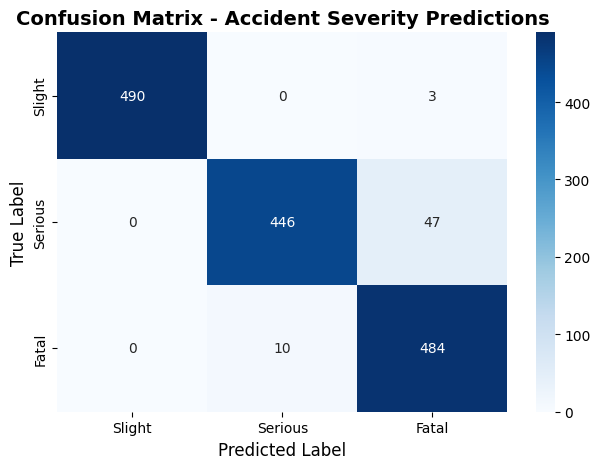

In [32]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Slight', 'Serious', 'Fatal'],
            yticklabels=['Slight', 'Serious', 'Fatal'])
plt.title('Confusion Matrix - Accident Severity Predictions', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()


## Visualizations - Feature Importance

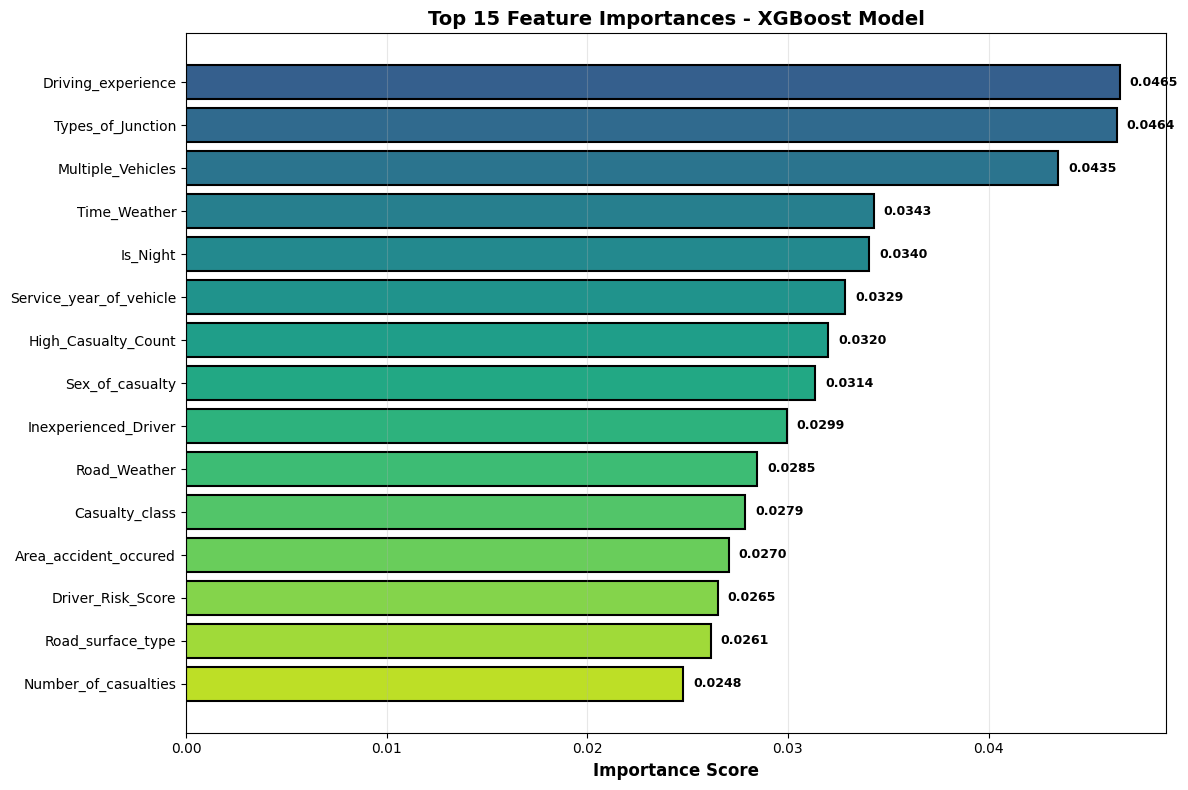

In [33]:
plt.figure(figsize=(12, 8))
top_15_idx = np.argsort(importances)[-15:][::-1]
top_15_names = [feature_names[i] for i in top_15_idx]
top_15_values = importances[top_15_idx]

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_15_names)))
bars = plt.barh(range(len(top_15_names)), top_15_values, color=colors, edgecolor='black', linewidth=1.5)

plt.yticks(range(len(top_15_names)), top_15_names)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('Top 15 Feature Importances - XGBoost Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()


for i, (bar, val) in enumerate(zip(bars, top_15_values)):
    plt.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Visualizations - Classification Metrics

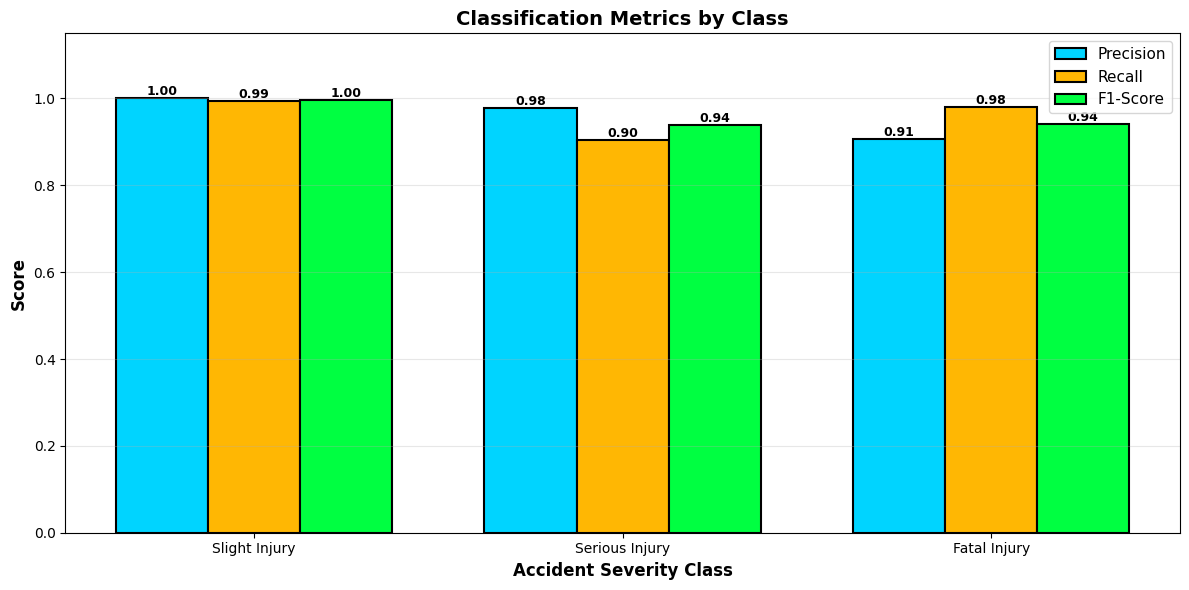

In [34]:
precision = precision_score(y_test, y_pred, average=None, zero_division=0)
recall = recall_score(y_test, y_pred, average=None, zero_division=0)
f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

x = np.arange(3)
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, precision, width, label='Precision', color='#00d4ff', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x, recall, width, label='Recall', color='#ffb703', edgecolor='black', linewidth=1.5)
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#00ff41', edgecolor='black', linewidth=1.5)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Accident Severity Class', fontsize=12, fontweight='bold')
ax.set_title('Classification Metrics by Class', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Slight Injury', 'Serious Injury', 'Fatal Injury'])
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## Summary & Key Insights

In [37]:
print(f"\n MODEL PERFORMANCE")
print(f"  • Overall Accuracy: {accuracy*100:.2f}%")
print(f"  • Weighted F1-Score: {weighted_f1:.4f}")
print(f"  • Macro F1-Score: {macro_f1:.4f}")

print(f"\n TOP 5 IMPORTANT FEATURES")
for i, idx in enumerate(top_indices[:5], 1):
    print(f"  {i}. {feature_names[idx]:<40} ({importances[idx]:.4f})")

print(f"\n CLASS-WISE PERFORMANCE")
class_names = ['Slight Injury', 'Serious Injury', 'Fatal Injury']
for i, class_name in enumerate(class_names):
    print(f"  • {class_name:<20} - Precision: {precision[i]:.2%} | Recall: {recall[i]:.2%} | F1: {f1[i]:.4f}")

print(f"\n DATA STATISTICS")
print(f"  • Original Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"  • After Feature Engineering: {df_engineered.shape[0]} rows, {df_engineered.shape[1]} columns")
print(f"  • After SMOTE Resampling: {X_resampled.shape[0]} rows")
print(f"  • Training Samples: {X_train.shape[0]}")
print(f"  • Test Samples: {X_test.shape[0]}")

print(f"\n PREDICTIONS")
print(f"  0 = Slight Injury")
print(f"  1 = Serious Injury")
print(f"  2 = Fatal Injury")



 MODEL PERFORMANCE
  • Overall Accuracy: 95.95%
  • Weighted F1-Score: 0.9595
  • Macro F1-Score: 0.9595

 TOP 5 IMPORTANT FEATURES
  1. Driving_experience                       (0.0465)
  2. Types_of_Junction                        (0.0464)
  3. Multiple_Vehicles                        (0.0435)
  4. Time_Weather                             (0.0343)
  5. Is_Night                                 (0.0340)

 CLASS-WISE PERFORMANCE
  • Slight Injury        - Precision: 100.00% | Recall: 99.39% | F1: 0.9969
  • Serious Injury       - Precision: 97.81% | Recall: 90.47% | F1: 0.9399
  • Fatal Injury         - Precision: 90.64% | Recall: 97.98% | F1: 0.9416

 DATA STATISTICS
  • Original Dataset: 12316 rows, 34 columns
  • After Feature Engineering: 12316 rows, 47 columns
  • After SMOTE Resampling: 7398 rows
  • Training Samples: 5918
  • Test Samples: 1480

 PREDICTIONS
  0 = Slight Injury
  1 = Serious Injury
  2 = Fatal Injury


##  Make Predictions on New Data

In [41]:
print("Feature Prediction")
sample_predictions = model.predict(X_test[:10])
sample_probabilities = model.predict_proba(X_test[:10])
actual = y_test[:10]

severity_map = {0: 'Slight Injury', 1: 'Serious Injury', 2: 'Fatal Injury'}

print(f"\n{'Sample':<10}{'Actual':<20}{'Predicted':<20}{'Confidence':<12}")
print("-"*70)

for i in range(10):
    actual_label = severity_map[actual.iloc[i] if hasattr(actual, 'iloc') else actual[i]]
    predicted_label = severity_map[sample_predictions[i]]
    confidence = np.max(sample_probabilities[i])

    status = "✓" if sample_predictions[i] == (actual.iloc[i] if hasattr(actual, 'iloc') else actual[i]) else "✗"
    print(f"{i+1:<10}{actual_label:<20}{predicted_label:<20}{confidence:<.2%}{status}")


Feature Prediction

Sample    Actual              Predicted           Confidence  
----------------------------------------------------------------------
1         Serious Injury      Serious Injury      86.21%✓
2         Serious Injury      Serious Injury      96.31%✓
3         Slight Injury       Slight Injury       98.19%✓
4         Fatal Injury        Fatal Injury        79.06%✓
5         Slight Injury       Slight Injury       74.36%✓
6         Fatal Injury        Serious Injury      56.42%✗
7         Serious Injury      Serious Injury      97.99%✓
8         Serious Injury      Serious Injury      70.14%✓
9         Fatal Injury        Fatal Injury        86.44%✓
10        Serious Injury      Serious Injury      95.57%✓
